Today's date: 2026-03-06

Latest SET index:
         date  setindex
0  2026-02-27   1528.26

First SET index of 2026:
         date  setindex
0  2026-01-05   1280.05

SET index change: 248.21 points (19.39%)
Period: 2026-01-05 to 2026-02-27

Active buy orders:
   period     name  shares
0       1    PTTGC    6000
1       1      SCC     600
2       1   SINGER    6000
3       1      STA   10000
4       2    3BBIF  120000
5       2  CPNREIT   55000
6       2      DIF   45000
7       2   GVREIT   69000
8       2      MCS   75000
9       2      NER   27000
10      2      PTT    7500
11      2     SENA  105000
12      2    TFFIF   20000
13      2    WHAIR   50000
14      2    WHART   20000
15      3   ADVANC     100
16      3       AH    1200
17      3      AWC    9000
18      3      BCH    4000
19      3      CPF   10000
20      3      PTG    3600
21      3      RCL   27000
22      3    SYNEX   17500
23      3      TOA    1000
24      3      TVO    4000
25      4   AIMIRT   17500
26      4 

C:\Users\User\AppData\Local\Temp\ipykernel_19124\630950379.py:253: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\User\AppData\Local\Temp\ipykernel_19124\630950379.py:254: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  plt.savefig('stock_performance_dashboard.png', dpi=150, bbox_inches='tight')
C:\Users\User\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 3647 (\N{THAI CURRENCY SYMBOL BAHT}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


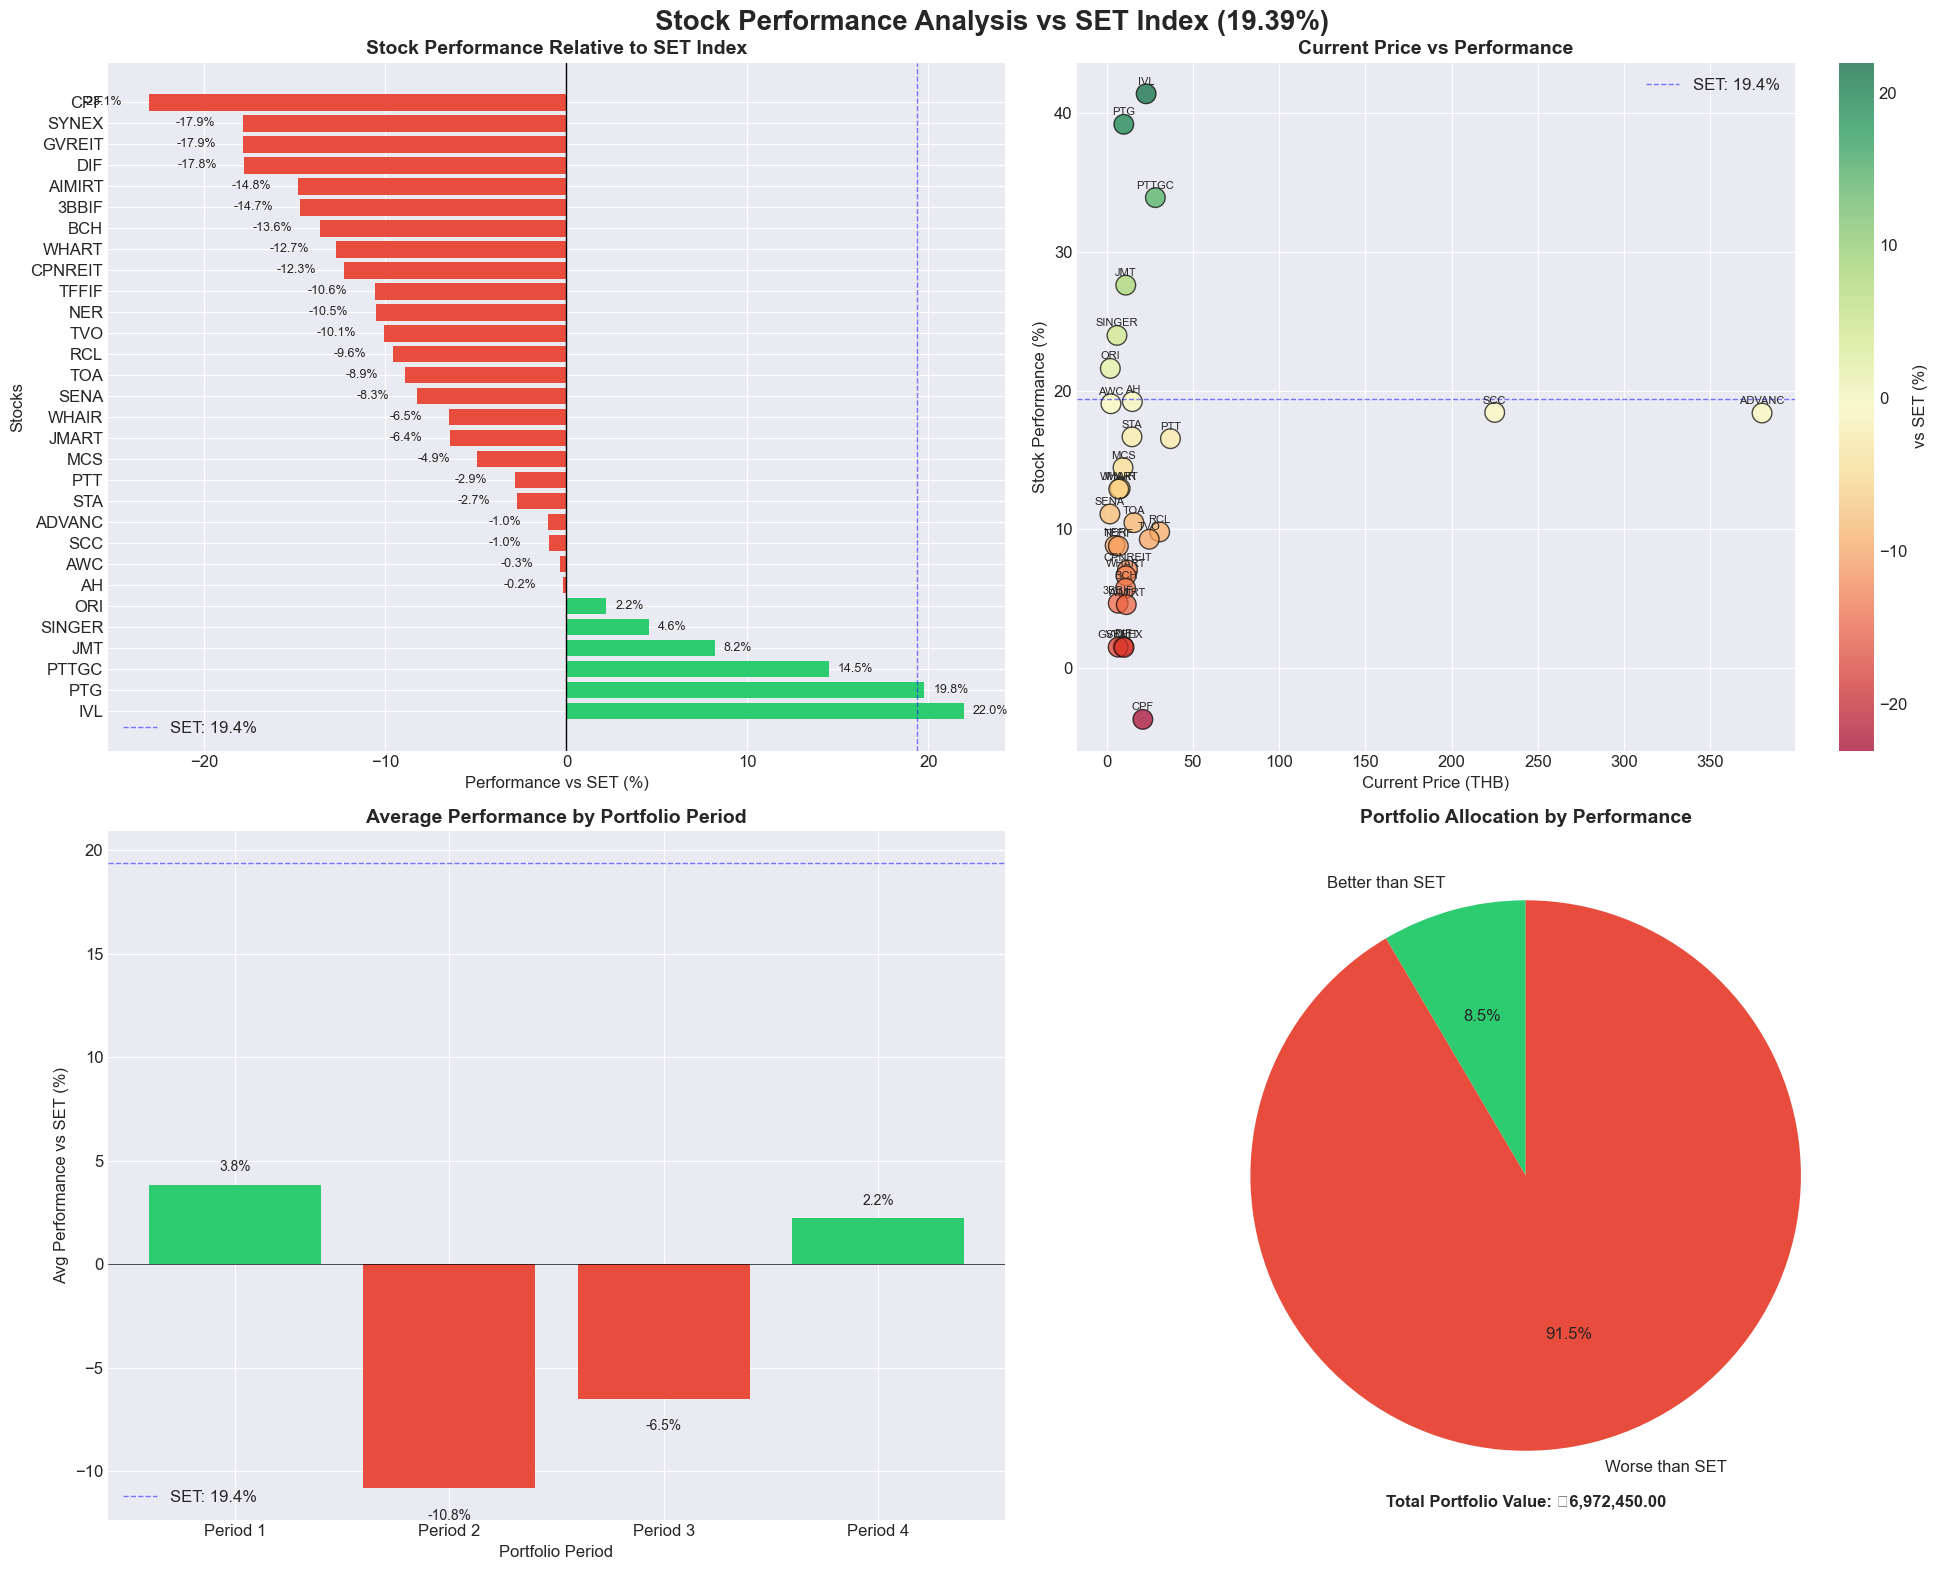

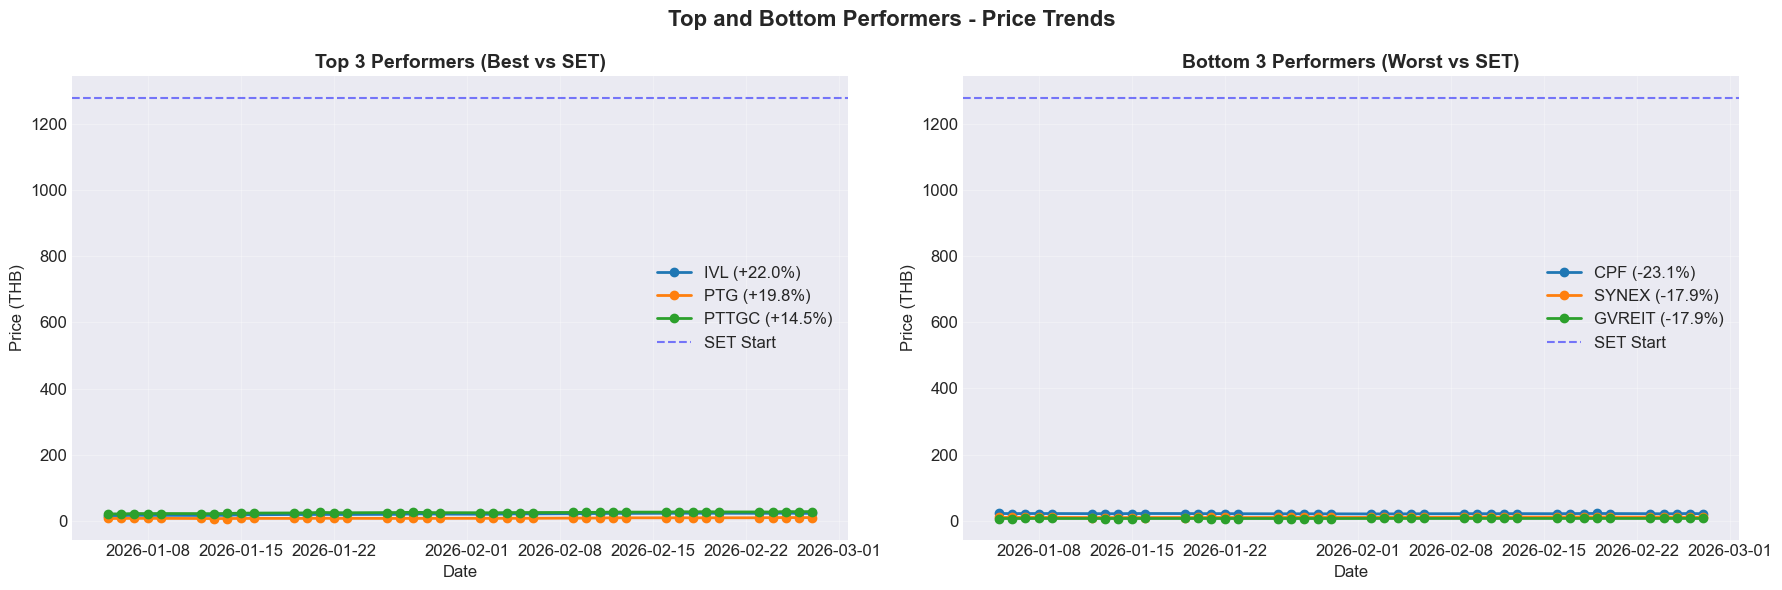


📈 STOCKS PERFORMING BETTER THAN SET:
period   name  pct_change  vs_set  current_value
     4    IVL       41.36   21.97      164880.00
     3    PTG       39.16   19.77       35820.00
     1  PTTGC       33.89   14.50      169500.00
     4    JMT       27.59    8.20       77700.00
     1 SINGER       23.97    4.58       36000.00
     4    ORI       21.59    2.20      107000.00

📉 STOCKS PERFORMING WORSE THAN SET:
period    name  pct_change  vs_set  current_value
     3      AH       19.20   -0.19       17880.00
     3     AWC       19.05   -0.34       22500.00
     1     SCC       18.42   -0.97      135000.00
     3  ADVANC       18.38   -1.01       38000.00
     1     STA       16.67   -2.72      147000.00
     2     PTT       16.54   -2.86      277500.00
     2     MCS       14.46   -4.93      712500.00
     4   JMART       12.95   -6.44       53380.00
     2   WHAIR       12.90   -6.49      350000.00
     2    SENA       11.11   -8.28      199500.00
     3     TOA       10.49   -8.

In [1]:
import calendar
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import FuncFormatter
from datetime import date, timedelta
from sqlalchemy import create_engine, text
from pandas.tseries.offsets import BDay

# Database connections
engine = create_engine("mysql+pymysql://root:@localhost:3306/stock")
const = engine.connect()

pd.options.display.float_format = '{:.2f}'.format

# Set up plotting style
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 12

today = date.today()
print(f"Today's date: {today}")

# Get latest SET index value
sql = "SELECT * FROM setindex ORDER BY date DESC LIMIT 1"
df_latest_set = pd.read_sql(sql, const)
print("\nLatest SET index:")
print(df_latest_set)

# Get first SET index of 2026
sql = "SELECT * FROM setindex WHERE year(date) = 2026 ORDER BY date ASC LIMIT 1"
df_first_set_2026 = pd.read_sql(sql, const)
print("\nFirst SET index of 2026:")
print(df_first_set_2026)

# Calculate SET index performance
set_diff = df_latest_set.iloc[0] - df_first_set_2026.iloc[0]
set_pct_change = ((df_latest_set['setindex'].iloc[0] - df_first_set_2026['setindex'].iloc[0]) / 
                  df_first_set_2026['setindex'].iloc[0] * 100)
print(f"\nSET index change: {set_diff['setindex']:.2f} points ({set_pct_change:.2f}%)")
print(f"Period: {df_first_set_2026['date'].iloc[0]} to {df_latest_set['date'].iloc[0]}")

# Get active buy orders
sql = '''
SELECT period, name, volbuy AS shares
FROM buy
WHERE active = 1
ORDER BY period, name
'''
df_buy = pd.read_sql(sql, const)
df_buy['shares'] = df_buy['shares'].astype('int64')
print("\nActive buy orders:")
print(df_buy)

# Get price data for all stocks in the buy list
stock_list = df_buy['name'].unique().tolist()
stock_list_str = "','".join(stock_list)

# Get price data for the period
sql = f"""
SELECT name, date, price, maxp, minp, qty, opnp
FROM price 
WHERE name IN ('{stock_list_str}')
AND date BETWEEN '{df_first_set_2026['date'].iloc[0]}' AND '{df_latest_set['date'].iloc[0]}'
ORDER BY name, date
"""
df_prices = pd.read_sql(sql, const)
print(f"\nRetrieved price data for {len(df_prices)} records")

# Calculate performance for each stock
def calculate_stock_performance(df_prices, df_buy, start_date, end_date, set_pct_change):
    """
    Calculate performance metrics for each stock compared to SET index
    """
    results = []
    
    for stock in df_buy['name'].unique():
        stock_data = df_prices[df_prices['name'] == stock].copy()
        
        if len(stock_data) > 0:
            # Get first and last price in the period
            first_price = stock_data.iloc[0]['price']
            last_price = stock_data.iloc[-1]['price']
            
            # Calculate price change
            price_change = last_price - first_price
            pct_change = (price_change / first_price * 100) if first_price > 0 else 0
            
            # Compare with SET
            vs_set = pct_change - set_pct_change
            
            # Get buy information
            buy_info = df_buy[df_buy['name'] == stock].iloc[0]
            
            # Calculate current value
            current_value = last_price * buy_info['shares']
            
            # Get min/max during period
            min_price = stock_data['minp'].min() if 'minp' in stock_data.columns else stock_data['price'].min()
            max_price = stock_data['maxp'].max() if 'maxp' in stock_data.columns else stock_data['price'].max()
            
            results.append({
                'period': buy_info['period'],
                'name': stock,
                'shares': buy_info['shares'],
                'first_price': first_price,
                'last_price': last_price,
                'min_price': min_price,
                'max_price': max_price,
                'price_change': price_change,
                'pct_change': pct_change,
                'set_pct_change': set_pct_change,
                'vs_set': vs_set,
                'current_value': current_value,
                'performance': 'Better' if vs_set > 0 else 'Worse' if vs_set < 0 else 'Equal'
            })
    
    return pd.DataFrame(results)

# Calculate performance
df_performance = calculate_stock_performance(
    df_prices, 
    df_buy, 
    df_first_set_2026['date'].iloc[0], 
    df_latest_set['date'].iloc[0],
    set_pct_change
)

# Sort by performance vs SET
df_performance = df_performance.sort_values('vs_set', ascending=False)

print("\n" + "="*80)
print("STOCK PERFORMANCE COMPARED TO SET INDEX")
print("="*80)
print(f"Period: {df_first_set_2026['date'].iloc[0]} to {df_latest_set['date'].iloc[0]}")
print(f"SET Index Change: {set_pct_change:.2f}%")
print("="*80)

# ============================================================================
# VISUALIZATION 1: Bar chart comparing stock performance to SET
# ============================================================================
fig, axes = plt.subplots(2, 2, figsize=(20, 16))
fig.suptitle(f'Stock Performance Analysis vs SET Index ({set_pct_change:.2f}%)', fontsize=20, fontweight='bold')

# 1.1 Bar chart - Performance vs SET
ax1 = axes[0, 0]
colors = ['#2ecc71' if x > 0 else '#e74c3c' if x < 0 else '#3498db' for x in df_performance['vs_set']]
bars = ax1.barh(range(len(df_performance)), df_performance['vs_set'], color=colors)
ax1.axvline(x=0, color='black', linestyle='-', linewidth=1)
ax1.axvline(x=set_pct_change, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'SET: {set_pct_change:.1f}%')
ax1.set_xlabel('Performance vs SET (%)', fontsize=12)
ax1.set_ylabel('Stocks', fontsize=12)
ax1.set_title('Stock Performance Relative to SET Index', fontsize=14, fontweight='bold')
ax1.set_yticks(range(len(df_performance)))
ax1.set_yticklabels(df_performance['name'])
ax1.legend()

# Add value labels
for i, (bar, val) in enumerate(zip(bars, df_performance['vs_set'])):
    width = bar.get_width()
    ax1.text(width + (0.5 if width >= 0 else -1.5), bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', ha='left' if width >= 0 else 'right', va='center', fontsize=9)

# 1.2 Scatter plot - Current Price vs Performance
ax2 = axes[0, 1]
scatter = ax2.scatter(df_performance['last_price'], df_performance['pct_change'], 
                      c=df_performance['vs_set'], cmap='RdYlGn', s=200, alpha=0.7, edgecolors='black', linewidth=1)
ax2.axhline(y=set_pct_change, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'SET: {set_pct_change:.1f}%')
ax2.set_xlabel('Current Price (THB)', fontsize=12)
ax2.set_ylabel('Stock Performance (%)', fontsize=12)
ax2.set_title('Current Price vs Performance', fontsize=14, fontweight='bold')
ax2.legend()

# Add labels for each point
for i, row in df_performance.iterrows():
    ax2.annotate(row['name'], (row['last_price'], row['pct_change']), 
                fontsize=8, ha='center', va='bottom', xytext=(0, 5), textcoords='offset points')

plt.colorbar(scatter, ax=ax2, label='vs SET (%)')

# ============================================================================
# VISUALIZATION 2: Performance by period
# ============================================================================
ax3 = axes[1, 0]

# Group by period
period_performance = df_performance.groupby('period').agg({
    'name': 'count',
    'vs_set': 'mean',
    'pct_change': 'mean',
    'current_value': 'sum'
}).reset_index()
period_performance.columns = ['period', 'stock_count', 'avg_vs_set', 'avg_pct', 'total_value']

# Bar chart for average performance by period
x_pos = np.arange(len(period_performance))
bars = ax3.bar(x_pos, period_performance['avg_vs_set'], 
               color=['#2ecc71' if x > 0 else '#e74c3c' for x in period_performance['avg_vs_set']])
ax3.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
ax3.axhline(y=set_pct_change, color='blue', linestyle='--', linewidth=1, alpha=0.5, label=f'SET: {set_pct_change:.1f}%')
ax3.set_xlabel('Portfolio Period', fontsize=12)
ax3.set_ylabel('Avg Performance vs SET (%)', fontsize=12)
ax3.set_title('Average Performance by Portfolio Period', fontsize=14, fontweight='bold')
ax3.set_xticks(x_pos)
ax3.set_xticklabels([f'Period {int(p)}' for p in period_performance['period']])
ax3.legend()

# Add value labels
for bar, val in zip(bars, period_performance['avg_vs_set']):
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height + (0.5 if height >= 0 else -1),
             f'{val:.1f}%', ha='center', va='bottom' if height >= 0 else 'top', fontsize=10)

# ============================================================================
# VISUALIZATION 3: Portfolio allocation pie chart
# ============================================================================
ax4 = axes[1, 1]

# Prepare data for pie chart
better_stocks = df_performance[df_performance['vs_set'] > 0]
worse_stocks = df_performance[df_performance['vs_set'] < 0]
equal_stocks = df_performance[df_performance['vs_set'] == 0]

# Portfolio allocation by performance category
portfolio_by_performance = {
    'Better than SET': better_stocks['current_value'].sum(),
    'Worse than SET': worse_stocks['current_value'].sum(),
    'Equal to SET': equal_stocks['current_value'].sum()
}

# Filter out zero values
portfolio_by_performance = {k: v for k, v in portfolio_by_performance.items() if v > 0}

if portfolio_by_performance:
    colors_pie = ['#2ecc71', '#e74c3c', '#3498db']
    wedges, texts, autotexts = ax4.pie(portfolio_by_performance.values(), 
                                        labels=portfolio_by_performance.keys(),
                                        autopct='%1.1f%%',
                                        colors=colors_pie[:len(portfolio_by_performance)],
                                        startangle=90,
                                        textprops={'fontsize': 12})
    ax4.set_title('Portfolio Allocation by Performance', fontsize=14, fontweight='bold')
    
    # Add total value
    total_value = df_performance['current_value'].sum()
    ax4.text(0, -1.2, f'Total Portfolio Value: ฿{total_value:,.2f}', 
             ha='center', fontsize=12, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'No portfolio data available', ha='center', va='center', fontsize=12)

plt.tight_layout()
plt.savefig('stock_performance_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# VISUALIZATION 4: Individual stock performance timeline (for top/bottom performers)
# ============================================================================
fig2, axes2 = plt.subplots(1, 2, figsize=(18, 6))
fig2.suptitle('Top and Bottom Performers - Price Trends', fontsize=16, fontweight='bold')

# Get top 3 and bottom 3 performers
top_performers = df_performance.nlargest(3, 'vs_set')
bottom_performers = df_performance.nsmallest(3, 'vs_set')

# Plot top performers
ax_top = axes2[0]
for _, row in top_performers.iterrows():
    stock_data = df_prices[df_prices['name'] == row['name']].copy()
    if len(stock_data) > 0:
        stock_data['date'] = pd.to_datetime(stock_data['date'])
        ax_top.plot(stock_data['date'], stock_data['price'], marker='o', linewidth=2, label=f"{row['name']} (+{row['vs_set']:.1f}%)")
ax_top.axhline(y=df_first_set_2026['setindex'].iloc[0], color='blue', linestyle='--', alpha=0.5, label='SET Start')
ax_top.set_xlabel('Date', fontsize=12)
ax_top.set_ylabel('Price (THB)', fontsize=12)
ax_top.set_title('Top 3 Performers (Best vs SET)', fontsize=14, fontweight='bold')
ax_top.legend(loc='best')
ax_top.grid(True, alpha=0.3)

# Plot bottom performers
ax_bottom = axes2[1]
for _, row in bottom_performers.iterrows():
    stock_data = df_prices[df_prices['name'] == row['name']].copy()
    if len(stock_data) > 0:
        stock_data['date'] = pd.to_datetime(stock_data['date'])
        ax_bottom.plot(stock_data['date'], stock_data['price'], marker='o', linewidth=2, label=f"{row['name']} ({row['vs_set']:.1f}%)")
ax_bottom.axhline(y=df_first_set_2026['setindex'].iloc[0], color='blue', linestyle='--', alpha=0.5, label='SET Start')
ax_bottom.set_xlabel('Date', fontsize=12)
ax_bottom.set_ylabel('Price (THB)', fontsize=12)
ax_bottom.set_title('Bottom 3 Performers (Worst vs SET)', fontsize=14, fontweight='bold')
ax_bottom.legend(loc='best')
ax_bottom.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('top_bottom_performers.png', dpi=150, bbox_inches='tight')
plt.show()

# ============================================================================
# Display results in console
# ============================================================================
print("\n📈 STOCKS PERFORMING BETTER THAN SET:")
better_stocks = df_performance[df_performance['vs_set'] > 0]
if len(better_stocks) > 0:
    print(better_stocks[['period', 'name', 'pct_change', 'vs_set', 'current_value']].to_string(index=False))
else:
    print("No stocks performing better than SET")

print("\n📉 STOCKS PERFORMING WORSE THAN SET:")
worse_stocks = df_performance[df_performance['vs_set'] < 0]
if len(worse_stocks) > 0:
    print(worse_stocks[['period', 'name', 'pct_change', 'vs_set', 'current_value']].to_string(index=False))
else:
    print("No stocks performing worse than SET")

print("\n⚖️ STOCKS PERFORMING EQUAL TO SET:")
equal_stocks = df_performance[df_performance['vs_set'] == 0]
if len(equal_stocks) > 0:
    print(equal_stocks[['period', 'name', 'pct_change', 'vs_set', 'current_value']].to_string(index=False))
else:
    print("No stocks performing equal to SET")

# Summary statistics
print("\n" + "="*80)
print("SUMMARY STATISTICS")
print("="*80)

total_investment = (df_performance['first_price'] * df_performance['shares']).sum()
total_current_value = df_performance['current_value'].sum()
total_pnl = total_current_value - total_investment
total_pnl_pct = (total_pnl / total_investment * 100) if total_investment > 0 else 0

print(f"Total Investment: {total_investment:,.2f}")
print(f"Total Current Value: {total_current_value:,.2f}")
print(f"Total P&L: {total_pnl:,.2f} ({total_pnl_pct:.2f}%)")
print(f"VS SET: {total_pnl_pct - set_pct_change:.2f}%")

print(f"\nBetter than SET: {len(better_stocks)} stocks")
print(f"Worse than SET: {len(worse_stocks)} stocks")
print(f"Equal to SET: {len(equal_stocks)} stocks")

# Save results to CSV
output_file = f'stock_performance_vs_set_{today.strftime("%Y%m%d")}.csv'
df_performance.to_csv(output_file, index=False)
print(f"\nResults saved to {output_file}")

# Close database connection
const.close()